# Importación de Librerías

En esta sección se importan las librerías necesarias para el análisis y limpieza de datos.

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from pickletools import decimalnl_long
from sklearn.inspection._plot import decision_boundary
from sklearn.model_selection import cross_val_score
from traitlets.config import DeferredConfigString

pd.options.future.infer_string = False

## Carga y Exploración Inicial

Se carga el dataset y se realiza una inspección inicial.

In [7]:
df = pd.read_csv('../datasets/Telco_Customer_Churn_Clean.csv')


In [8]:
#Visualizar datos preliminares del dataset

print('Dataset cargado:', df.shape)
print('\nColumnas del dataset Listo y Preparado para ML:')
print(list(df.columns))
print('\nTipo de datos:')
print(df.dtypes)

Dataset cargado: (7032, 23)

Columnas del dataset Listo y Preparado para ML:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'TotalServices']

Tipo de datos:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService      object
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges       

## Identificando columnas utiles

Se analizaran todas las columnas y se tomaran solo las unicas columnas que el modelo puede usar para aprender.

In [9]:
columnas_descartadas = ['customerID']

df_ml = df.drop(columns=columnas_descartadas)
print('Columnas del dataset Limpio y Listo para ML:')
print(list(df_ml.columns))
print('\nForma del dataset', df_ml.shape)

Columnas del dataset Limpio y Listo para ML:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'TotalServices']

Forma del dataset (7032, 22)


## Trabajando con las Variables "X" e "Y"

La variable "X" es la que estara analizando usara los features para aprender. Por otro lado tendremos la variable "Y" que sera la que el modelo tratara de predecir.

In [32]:
X = df_ml.drop(columns=['Churn'])
y= df_ml['Churn']

print("La variable 'X' features que el modelo usara para aprender" )
print("  shape:", X.shape)
print("  Columnas:", list(X.columns))
print()
print("La variable 'Y' es la variable que el modelo intentara predecir")
print("  shape:", y.shape)
print("  Valores Unicos:", y.unique()) # Este metodo mostrara valores distintos
print("\n  Distribucion:", y.value_counts() )




La variable 'X' features que el modelo usara para aprender
  shape: (7032, 21)
  Columnas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'TotalServices']

La variable 'Y' es la variable que el modelo intentara predecir
  shape: (7032,)
  Valores Unicos: [0 1]

  Distribucion: Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    73.42
1    26.58
Name: count, dtype: float64


## Paso 3. Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Tamaño del split:")
print(f"  X_train: {X_train.shape} - Informacion con la que el modelo aprende")
print(f"  X_test: {X_test.shape} - Informacion con la que se evalua el modelo")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")
print()
print("Proporcion de Abandono en train", round(y_train.mean(),4))
print("Proporcion de Abandono en test", round(y_test.mean(),4))

Tamaño del split:
  X_train: (5625, 21) - Informacion con la que el modelo aprende
  X_test: (1407, 21) - Informacion con la que se evalua el modelo
  y_train: (5625,)
  y_test: (1407,)

Proporcion de Abandono en train 0.2658
Proporcion de Abandono en test 0.2658


## Paso 4. Encoding

In [124]:
print(list(df.columns))

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'TotalServices']


In [14]:
columnas_categoricas = X.select_dtypes(include='object').columns
print('Columnas a codificar: ', columnas_categoricas)
print()

X_train_enc = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=False)
X_test_enc = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=False)

#alinear columnas
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

#Comparacion
print("Columnas ANTES del encoding: ", X_train.shape[1])
print("Columnas DESPUES del encoding: ", X_train_enc.shape[1])
print()

print('Informacion de X_train')
print(list(X_train.columns))
print()
print("Nueva Info de las columnas:")
print(list(X_train_enc.columns))

Columnas a codificar:  Index(['gender', 'Partner', 'Dependents', 'InternetService', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TenureGroup'],
      dtype='object')

Columnas ANTES del encoding:  21
Columnas DESPUES del encoding:  35

Informacion de X_train
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'TotalServices']

Nueva Info de las columnas:
['SeniorCitizen', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'I

### Paso 5. Escalado de Variables Numéricas

Se utilizara **StandardScaler**, el cual transforma cada variable para que tenga una media cercana a 0 y una desviación estándar cercana a 1.

Las variables binarias generadas mediante One-Hot Encoding no serán escaladas, ya que sus valores ya se encuentran en un rango adecuado (0 y 1).

In [15]:
columnas_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']

scaler = StandardScaler()

X_train_enc[columnas_numericas] = scaler.fit_transform(X_train_enc[columnas_numericas])
X_test_enc[columnas_numericas] = scaler.transform(X_test_enc[columnas_numericas])

print("Estadisticas de las variables numericas en X_train_enc:")
print(X_train_enc[columnas_numericas].describe().round(3))
print()
print("\nMedia de las variables numericas")
print(X_train_enc[columnas_numericas].mean().round(4))
print("\nDesviacion Standard de las variables numericas")
print(X_train_enc[columnas_numericas].std().round(4))


Estadisticas de las variables numericas en X_train_enc:
         tenure  MonthlyCharges  TotalCharges  TotalServices
count  5625.000        5625.000      5625.000       5625.000
mean     -0.000          -0.000         0.000          0.000
std       1.000           1.000         1.000          1.000
min      -1.277          -1.539        -0.996         -1.632
25%      -0.951          -0.978        -0.829         -1.147
50%      -0.136           0.187        -0.392         -0.176
75%       0.924           0.835         0.659          0.795
max       1.617           1.792         2.830          2.251


Media de las variables numericas
tenure           -0.0
MonthlyCharges   -0.0
TotalCharges      0.0
TotalServices     0.0
dtype: float64

Desviacion Standard de las variables numericas
tenure            1.0001
MonthlyCharges    1.0001
TotalCharges      1.0001
TotalServices     1.0001
dtype: float64


### Interpretación

El proceso de estandarización fue aplicado correctamente a las variables numéricas del conjunto de entrenamiento, obteniendo una media cercana a **0** y una desviación estándar cercana a **1**. Posteriormente, el mismo escalador fue utilizado sobre el conjunto de prueba sin recalcular los parámetros, evitando la fuga de información (*data leakage*) y dejando los datos preparados para el entrenamiento de modelos de Machine Learning.

## Paso 6. Verificación Final

Antes de entrenar un modelo de Machine Learning es importante comprobar que el proceso de preparación de datos se realizó correctamente. En esta etapa se verificará que:

- El tamaño de los conjuntos de entrenamiento y prueba sea el esperado.
- No existan valores nulos.
- Todas las variables sean numéricas.
- Las dimensiones de los datasets sean consistentes.

In [16]:
#convertir columnas booleanas a enteros

bool_columnas = X_train_enc.select_dtypes(include='bool').columns

X_train_enc[bool_columnas] = X_train_enc[bool_columnas].astype('int64')
X_test_enc[bool_columnas] = X_test_enc[bool_columnas].astype('int64')

print("X_train_enc:", X_train_enc.shape)
print("X_test_enc:", X_test_enc.shape)
print("y_train:", y_train.shape)
print('y_test:', y_test.shape)
print()

print("\nEstadísticas de tenure en train:")
print(y_train.describe())

print("\nEstadísticas de tenure en test:")
print(y_test.describe())

print("Valores nulos en X_train", X_train_enc.isnull().sum().sum())
print("Valores nulos en X_test", X_test_enc.isnull().sum().sum())
print()

print("Tipos de datos en X_train")
print(X_train_enc.dtypes.value_counts())
print()

print("Columnas finales utilizadas por el modelo:")
print(list(X_train_enc.columns))

X_train_enc: (5625, 35)
X_test_enc: (1407, 35)
y_train: (5625,)
y_test: (1407,)


Estadísticas de tenure en train:
count    5625.000000
mean        0.265778
std         0.441786
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Churn, dtype: float64

Estadísticas de tenure en test:
count    1407.000000
mean        0.265814
std         0.441923
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Churn, dtype: float64
Valores nulos en X_train 0
Valores nulos en X_test 0

Tipos de datos en X_train
int64      31
float64     4
Name: count, dtype: int64

Columnas finales utilizadas por el modelo:
['SeniorCitizen', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Depen

### Interpretación

La verificación final confirma que el proceso de preparación de datos fue completado correctamente. Los conjuntos de entrenamiento y prueba presentan las dimensiones esperadas, no contienen valores nulos y todas las variables se encuentran en formato numérico, requisito indispensable para la mayoría de los algoritmos de Machine Learning.

Además, las variables categóricas fueron transformadas mediante One-Hot Encoding y las variables numéricas fueron estandarizadas utilizando **StandardScaler**, dejando el dataset completamente preparado para el entrenamiento y evaluación de modelos predictivos de clasificación.

### Modelo de clasificación: predecir el abandono


vamos a predecir Churn (si el cliente se va o no) a partir de su perfil, sus servicios, y sus montos de facturación. Este dataset está desbalanceado: recuerda diagnosticarlo antes de entrenar, igual que hicieron con el Titanic en el Mes 4 y 5.


Regresion Logisica

Modelo entrenado con 5625 Registros
Modelo Listo. Predicciones generadas: 1407 clientes  de prueba

Accuracy de un modelo que siempre predice 'No Churn' 0.7342
Accuracy de nuestro modelo real: 0.7868

Matriz de confusion
[[926 107]
 [193 181]]

Verdadero Negativo (VN): 926, predijo 'no churn' y acerto
Falso Positivo (FP): 107, predijo 'churn', pero no acerto
Falso Negativo (FN): 193, predijo 'no churn', pero no acerto
Verdadero Positivo (VP): 181, predijo 'churn' y acerto

Precision: 0.6285
Recall: 0.4840
F1: 0.5468


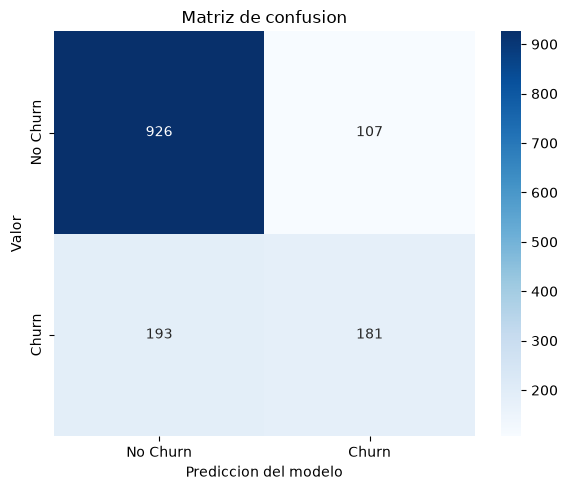

In [53]:
modelo_reg_log = LogisticRegression(max_iter=1000)
modelo_reg_log.fit(X_train_enc, y_train)

print("Modelo entrenado con", X_train_enc.shape[0], "Registros")

#prediccion y probabilidades
y_pred_log = modelo_reg_log.predict(X_test_enc)
y_proba_log = modelo_reg_log.predict_proba(X_test_enc)[:,1]

print("Modelo Listo. Predicciones generadas:", len(y_test), "clientes  de prueba")

# Baseline: modelo que siempre predice "No Churn"
prediccion_tonta = [0] * len(y_test)

accuracy_tonta = accuracy_score(y_test, prediccion_tonta)
acc_log = accuracy_score(y_test, y_pred_log)

print()
print(f"Accuracy de un modelo que siempre predice 'No Churn' {accuracy_tonta:.4f}")
print(f"Accuracy de nuestro modelo real: {acc_log:.4f}")

#Matriz de confusion Regresion logistica
matriz_conf_log = confusion_matrix(y_test, y_pred_log)

print("\nMatriz de confusion")
print(matriz_conf_log)
print()
print(F"Verdadero Negativo (VN): {matriz_conf_log[0][0]}, predijo 'no churn' y acerto")
print(F"Falso Positivo (FP): {matriz_conf_log[0][1]}, predijo 'churn', pero no acerto")
print(F"Falso Negativo (FN): {matriz_conf_log[1][0]}, predijo 'no churn', pero no acerto")
print(F"Verdadero Positivo (VP): {matriz_conf_log[1][1]}, predijo 'churn' y acerto")

#Vizualizar la Diagonal de confusion

plt.figure(figsize=(6,5))
sns.heatmap(matriz_conf_log, annot=True, fmt='d', cmap="Blues",
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.title("Matriz de confusion")
plt.xlabel('Prediccion del modelo')
plt.ylabel('Valor')
plt.tight_layout()
plt.savefig('confusion_matriz.png')


#Calculo de Recall, precision, f1_score
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
print()
print(f"Precision: {precision_log:.4f}")
print(f"Recall: {recall_log:.4f}")
print(f"F1: {f1_log:.4f}")

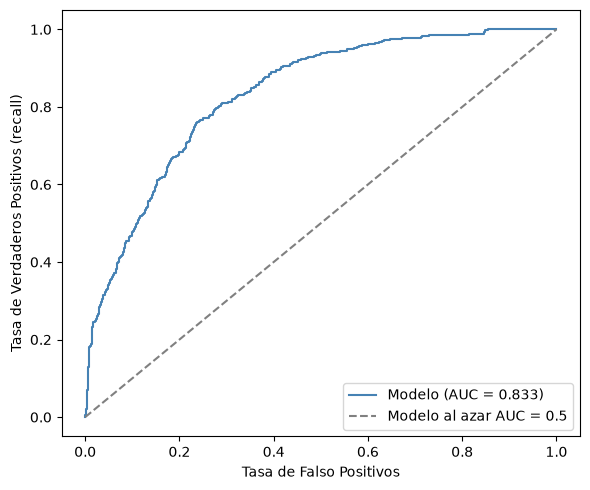

AUC (Area bajo la curva: 0.8330


In [70]:
#Curva ROC y AUC

fpr,tpr, umbrales = roc_curve(y_test, y_proba_log)
auc = roc_auc_score(y_test, y_proba_log)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='steelblue', label=f"Modelo (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], color='gray', linestyle='--', label="Modelo al azar AUC = 0.5")
plt.xlabel('Tasa de Falso Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (recall)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_auc_plot.png')
plt.show()

print(f"AUC (Area bajo la curva: {auc:.4f}")


Arbol de Decisiones

Modelo entrenado con 5625 registros

Metricas Arbol de Decision
  Accuracy: 0.7669
  Precision: 0.5537
  Recall: 0.6337
  F1: 0.5910
  AUC: 0.7244

Matriz de confusion
[[842 191]
 [137 237]]


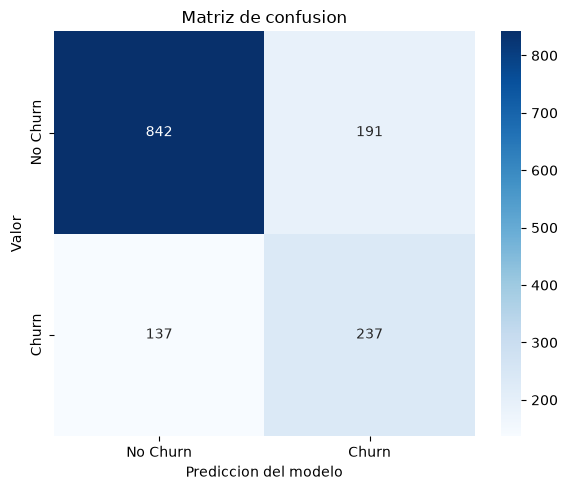

In [68]:
modelo_arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_arbol.fit(X_train_enc, y_train)

y_pred_arbol = modelo_arbol.predict(X_test_enc)
y_proba_arbol = modelo_arbol.predict_proba(X_test_enc)[:,1]

print("Modelo entrenado con", X_train_enc.shape[0], "registros")

acc_arbol = accuracy_score(y_test, y_pred_arbol)
precision_arbol = precision_score(y_test, y_pred_arbol)
recall_arbol = recall_score(y_test, y_pred_arbol)
f1_arbol = f1_score(y_test, y_pred_arbol)
auc_arbol = roc_auc_score(y_test, y_pred_arbol)

print("\nMetricas Arbol de Decision")
print(f"  Accuracy: {acc_arbol:.4f}")
print(f"  Precision: {precision_arbol:.4f}")
print(f"  Recall: {recall_arbol:.4f}")
print(f"  F1: {f1_arbol:.4f}")
print(f"  AUC: {auc_arbol:.4f}")


#Matriz de confusion
matriz_conf_arbol = confusion_matrix(y_test, y_pred_arbol)
print("\nMatriz de confusion")
print(matriz_conf_arbol)

#Vizualizar la Diagonal de confusion

plt.figure(figsize=(6,5))
sns.heatmap(matriz_conf_arbol, annot=True, fmt='d', cmap="Blues",
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.title("Matriz de confusion")
plt.xlabel('Prediccion del modelo')
plt.ylabel('Valor')
plt.tight_layout()
plt.savefig('confusion_matriz_arbol_decisiones.png')
plt.show()

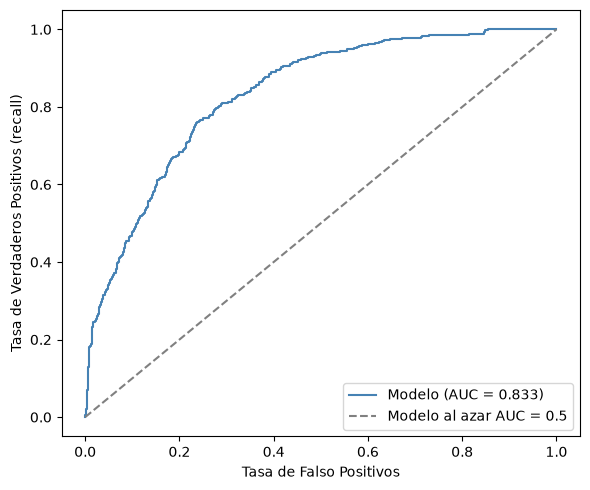

AUC (Area bajo la curva: 0.8330


In [71]:
#Curva ROC y AUC

fpr_arbol,tpr_arbol, umbrales_arbol = roc_curve(y_test, y_proba_log)
auc_arbol = roc_auc_score(y_test, y_proba_log)

plt.figure(figsize=(6,5))
plt.plot(fpr_arbol, tpr_arbol, color='steelblue', label=f"Modelo (AUC = {auc_arbol:.3f})")
plt.plot([0,1], [0,1], color='gray', linestyle='--', label="Modelo al azar AUC = 0.5")
plt.xlabel('Tasa de Falso Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (recall)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_auc_arbol_decision_plot.png')
plt.show()

print(f"AUC (Area bajo la curva: {auc_arbol:.4f}")

Comparacion de Modelos de Clasificacion

In [78]:
#Metricas

# Comparacion de los modelos

comparacion_modelos = pd.DataFrame({
    'Regresion Logistica': [
        acc_log,
        precision_log,
        recall_log,
        f1_log,
        auc
    ],
    'Arbol de Decision': [
        acc_arbol,
        precision_arbol,
        recall_arbol,
        f1_arbol,
        auc_arbol
    ]
}, index=[
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'AUC'
])

print("Comparacion de modelos:")
print()
print(comparacion_modelos.round(4))


Comparacion de modelos:

           Regresion Logistica  Arbol de Decision
Accuracy                0.7868             0.7669
Precision               0.6285             0.5537
Recall                  0.4840             0.6337
F1                      0.5468             0.5910
AUC                     0.8330             0.8330


In [79]:
# Extraer errores de las matrices de confusion

vn_log, fp_log, fn_log, vp_log = matriz_conf_log.ravel()
vn_arbol, fp_arbol, fn_arbol, vp_arbol = matriz_conf_arbol.ravel()

errores_modelos = pd.DataFrame({
    'Regresion Logistica': [
        fp_log,
        fn_log
    ],
    'Arbol de Decision': [
        fp_arbol,
        fn_arbol
    ]
}, index=[
    'Falsos Positivos',
    'Falsos Negativos'
])

print("\nComparacion de Errores")
print(errores_modelos)


Comparacion de Errores
                  Regresion Logistica  Arbol de Decision
Falsos Positivos                  107                191
Falsos Negativos                  193                137


### Elección del modelo

Luego de comparar ambos modelos, seleccionaría el **Árbol de Decisión** para la predicción de Churn.

Aunque la Regresión Logística obtuvo mayor Accuracy (0.7868) y Precision (0.6285), el Árbol de Decisión logró un **Recall considerablemente mayor (0.6337 vs. 0.4840)** y un mejor **F1-Score (0.5910 vs. 0.5468)**. Además, redujo los falsos negativos de **193 a 137**.

Para este problema considero más costoso no detectar a un cliente que realmente va a abandonar que identificar incorrectamente a uno como posible Churn. Por esta razón, priorizo el mayor Recall y la reducción de falsos negativos del Árbol de Decisión, aun sacrificando parte de la Precision y Accuracy.

### Validación

Confirmar, con evidencia, que al menos uno de los modelos no está memorizando.

REQUISITOS DE ESTA PARTE
- Para el modelo de clasificación: compara accuracy en train contra accuracy en test. Si la brecha es grande, ese es un candidato real a overfitting.
- Aplica cross-validation (cv=5) a al menos uno de tus dos modelos, y reporta la media y la desviación estándar de los folds.
- Si detectas overfitting, ajusta un hiperparámetro (por ejemplo, max_depth en el árbol) y muestra el resultado antes y después del ajuste.

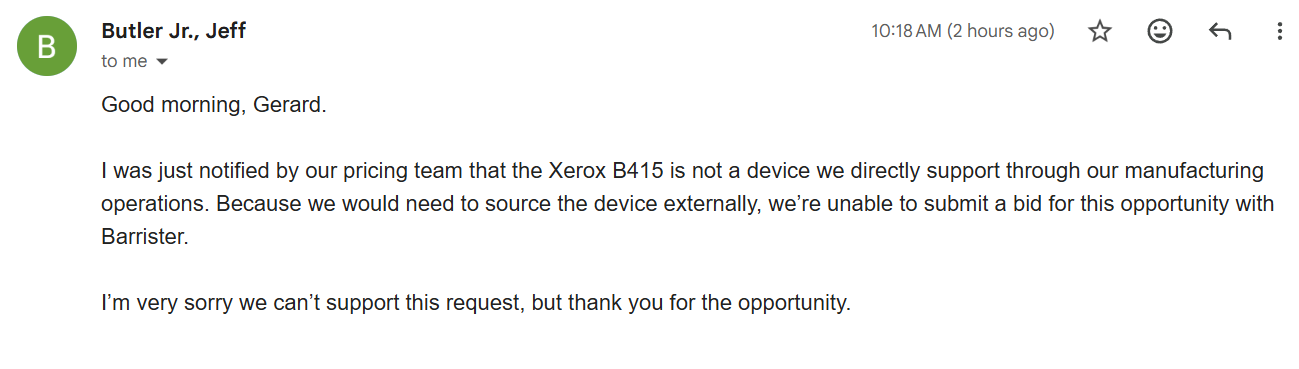

In [82]:
arbol_profundo = DecisionTreeClassifier(max_depth=None, random_state=0)
arbol_profundo.fit(X_train_enc, y_train)

#Para verificar que no hay overfitting, esto mido y compara los numeros de predicciones entre si en base los datos de entrenamiento
acc_train_profundo = accuracy_score(y_train, arbol_profundo.predict(X_train_enc))
acc_test_profundo = accuracy_score(y_test, arbol_profundo.predict(X_test_enc))

print()
print("Arbol sin limite de profundidad")
print(f"  Accuracy en Entrenamiento: {acc_train_profundo:.4f}")
print(f"  Accuracy en Prueba: {acc_test_profundo:.4f}")
print(f"  Diferencia (brecha): {acc_train_profundo - acc_test_profundo:.4f}")




Arbol sin limite de profundidad
  Accuracy en Entrenamiento: 0.9977
  Accuracy en Prueba: 0.7242
  Diferencia (brecha): 0.2735


In [84]:
#comparativa con un Arbol Simple

arbol_simple = DecisionTreeClassifier(max_depth=4, random_state=42)
arbol_simple.fit(X_train_enc, y_train)

#Comparando Accuracy en Train y en Test
acc_train_simple = accuracy_score(y_train, arbol_simple.predict(X_train_enc))
acc_test_simple = accuracy_score(y_test, arbol_simple.predict(X_test_enc))

print()
print("Arbol con nivel de profundidad=4")
print(f"  Accuracy en Entrenamiento: {acc_train_simple:.4f}")
print(f"  Accuracy en Prueba: {acc_test_simple:.4f}")
print(f"  Diferencia (brecha): {acc_train_simple - acc_test_simple:.4f}")



Arbol con nivel de profundidad=4
  Accuracy en Entrenamiento: 0.7945
  Accuracy en Prueba: 0.7669
  Diferencia (brecha): 0.0276


In [86]:
#Evaluando el modelo para underfitting

arbol_underfitting = DecisionTreeClassifier(max_depth=1, random_state=42)
arbol_underfitting.fit(X_train_enc, y_train)

acc_train_underfitting = accuracy_score(y_train, arbol_underfitting.predict(X_train_enc))
acc_test_underfitting = accuracy_score(y_test, arbol_underfitting.predict(X_test_enc))

print("Arbol con nivel de profundidad=1")
print(f"  Accuracy en Entrenamiento: {acc_train_underfitting:.4f}")
print(f"  Accuracy en Prueba: {acc_test_underfitting:.4f}")
print(f"  Diferencia (brecha): {acc_train_underfitting - acc_test_underfitting:.4f}")



Arbol con nivel de profundidad=1
  Accuracy en Entrenamiento: 0.7342
  Accuracy en Prueba: 0.7342
  Diferencia (brecha): 0.0000


In [87]:
#Cross Validation

modelo_cv = DecisionTreeClassifier(max_depth=4, random_state=42)
resultado_cv = cross_val_score(modelo_cv, X_train_enc, y_train, cv=5)

print("Resultados de cada uno de los 5 folds:")
print(resultado_cv.round(4))
print()
print(f"Media: {resultado_cv.mean()}")
print(f"Desviacion Estandard: {resultado_cv.std()}")

Resultados de cada uno de los 5 folds:
[0.7867 0.7858 0.7742 0.7911 0.8107]

Media: 0.7896888888888889
Desviacion Estandard: 0.011880557828695895


In [91]:
#Evaluacion con multiples niveles de profundidad.

print("Comparativa de Accuracy con multiples niveles de profundidad en Train y en Test:")
print()
for profundidad in [2,4,6,8,10, None]:
    modelo_prueba = DecisionTreeClassifier(max_depth=profundidad, random_state=42)
    modelo_prueba.fit(X_train_enc, y_train)

    acc_train_final = accuracy_score(y_train, modelo_prueba.predict(X_train_enc))
    acc_test_final = accuracy_score(y_test, modelo_prueba.predict(X_test_enc))

    print(f"max_depth={str(profundidad):>4} | Entrenamiento={acc_train_final:.4f} | Prueba={acc_test_final:.4f} | Brecha={acc_train_final - acc_test_final:.4f}")


Comparativa de Accuracy con multiples niveles de profundidad en Train y en Test:

max_depth=   2 | Entrenamiento=0.7668 | Prueba=0.7434 | Brecha=0.0233
max_depth=   4 | Entrenamiento=0.7945 | Prueba=0.7669 | Brecha=0.0276
max_depth=   6 | Entrenamiento=0.8153 | Prueba=0.7662 | Brecha=0.0491
max_depth=   8 | Entrenamiento=0.8427 | Prueba=0.7719 | Brecha=0.0708
max_depth=  10 | Entrenamiento=0.8766 | Prueba=0.7385 | Brecha=0.1382
max_depth=None | Entrenamiento=0.9977 | Prueba=0.7193 | Brecha=0.2784


### Validación y ajuste del Árbol de Decisión

Durante la validación se observó que el árbol sin límite de profundidad presentó
**overfitting**, alcanzando un Accuracy de **0.9977 en entrenamiento** y **0.7242
en prueba**, con una brecha de **0.2735**.

Al limitar `max_depth=4`, la brecha disminuyó considerablemente a **0.0276**,
obteniendo 0.7945 en entrenamiento y 0.7669 en prueba, mostrando una mejor
capacidad de generalización.

También se probó `max_depth=1`, obteniendo **0.7342 tanto en train como en test**.
Aunque no existe brecha, el rendimiento es prácticamente igual al baseline,
lo que indica **underfitting** por la baja complejidad del modelo.

Finalmente, mediante Cross-Validation con 5 folds para `max_depth=4` se obtuvo
una media de Accuracy de **0.7897** y una desviación estándar de **0.0119**,
indicando un comportamiento relativamente estable entre diferentes muestras
de entrenamiento.

### Probar el modelo con un cliente nuevo o desconocido 

In [98]:
cliente_nuevo = pd.DataFrame([{
    'customerID': 'NEW-0001',
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 6,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 90.00,
    'TotalCharges': 540.00,
    'Churn': 0,
    'TenureGroup': 'Nuevo',
    'TotalServices': 4
}])

client_arbol = cliente_nuevo.copy()
columnas_eliminar_arbol = ['customerID', 'Churn']
client_arbol = client_arbol.drop(columns=columnas_eliminar_arbol)

#one-hot encoding
client_arbol_enc = pd.get_dummies(client_arbol)

#Alinear columnas con X_train
client_arbol_enc = client_arbol_enc.reindex(columns=X_train_enc.columns, fill_value=0)

#Comprobar que el cliente nuevo este alineado y listo para usarlo con el modelo
print('Dimensiones del Cliente Nuevo:',client_arbol_enc.shape[1])
print('Dimensiones del X_train:',X_train_enc.shape[1])

#Convertir columnas booleanas a int
Columnas_bool_nuevo_cliente = client_arbol_enc.select_dtypes('bool').columns
client_arbol_enc[Columnas_bool_nuevo_cliente] = client_arbol_enc[Columnas_bool_nuevo_cliente].astype('int')

#Standard-Scaler
print("\nColumnas numericas: ")
print(client_arbol_enc[columnas_numericas])
client_arbol_enc[columnas_numericas] = scaler.transform(client_arbol_enc[columnas_numericas])

#Validacion final de nuevo cliente antes de pasarla al modelo:
print('\nTipos de datos del nuevo cliente')
print(client_arbol_enc.dtypes.value_counts())
print()
print("Tiene las mismas columnas que X_train?:",
      client_arbol_enc.columns.equals(X_train_enc.columns))

Dimensiones del Cliente Nuevo: 35
Dimensiones del X_train: 35

Columnas numericas: 
   tenure  MonthlyCharges  TotalCharges  TotalServices
0       6            90.0         540.0              4

Tipos de datos del nuevo cliente
int64      31
float64     4
Name: count, dtype: int64

Tiene las mismas columnas que X_train?: True


In [104]:
#Usar el nuevo cliente con el modelo

churn_predicho = modelo_arbol.predict(client_arbol_enc)
probablidad_churn = modelo_arbol.predict_proba(client_arbol_enc)[:,1]

if churn_predicho[0] == 1:
    print("Prediccion: Churn")
else:
    print("Prediccion: No Churn")

print(f"Probabilidad de Churn: {probablidad_churn[0]:.2%}")

Prediccion: Churn
Probabilidad de Churn: 64.35%


### Interpretacion del Nuevo/Desconocido cliente

El modelo de clasificación identifica un riesgo de abandono del 64%, clasificándolo como un cliente propenso a cancelar el servicio. Esto podría indicar la necesidad de aplicar estrategias de retención para perfiles similares.